In [83]:
!pip install openai
!pip install python-dotenv
!pip install groq


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [84]:
import re           # regex — pattern matching in text
import warnings     # suppresses noisy library warnings
from dataclasses import dataclass, field, asdict  # clean data containers
from typing import Dict, List, Optional, Tuple    # type hints for safer, clearer code
from pathlib import Path                           # cross-platform file paths

import json
import pandas as pd
from groq import Groq

import os
from pydantic import BaseModel, Field
from openai import OpenAI

client = OpenAI(api_key=os.getenv("OPENAI_API_KEY"))

warnings.filterwarnings("ignore")
from dotenv import load_dotenv
load_dotenv()


True

In [85]:
# ─────────────────────────────────────────────────────────────────────────────
# Dataset Configuration
# ─────────────────────────────────────────────────────────────────────────────

# Paths to pre-processed parquet files (adjust if your folder structure differs)
DATA_PATHS: Dict[str, Path] = {
    "gaia"      : Path("../datasets/processed/gaia.parquet"),
    "aime"      : Path("../datasets/processed/aime.parquet"),
    "mmlu_pro"  : Path("../datasets/processed/mmlu_pro.parquet"),
    "musique"   : Path("../datasets/processed/musique.parquet"),
    "swe_bench" : Path("../datasets/processed/swe_bench.parquet"),
}

# Where to save scored outputs
OUTPUT_DIR = Path("data/processed")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)  # create folder if it doesn't exist

print("✅ Configuration set.")
print(f"   Output directory: {OUTPUT_DIR.resolve()}")
print("   Datasets configured:")
for name, path in DATA_PATHS.items():
    exists = "✓" if path.exists() else "✗ (not found)"
    print(f"     {name:<12} → {path}  {exists}")

✅ Configuration set.
   Output directory: /Users/poorna/Downloads/research/notebooks/data/processed
   Datasets configured:
     gaia         → ../datasets/processed/gaia.parquet  ✓
     aime         → ../datasets/processed/aime.parquet  ✓
     mmlu_pro     → ../datasets/processed/mmlu_pro.parquet  ✓
     musique      → ../datasets/processed/musique.parquet  ✓
     swe_bench    → ../datasets/processed/swe_bench.parquet  ✓


In [86]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 4 — Load Datasets
# ─────────────────────────────────────────────────────────────────────────────
datasets: Dict[str, pd.DataFrame] = {}

for name, path in DATA_PATHS.items():
    df = pd.read_parquet(path)
    datasets[name] = df
    print(f"\n{'─' * 60}")
    print(f"📂 Dataset : {name.upper()}")
    print(f"   Path    : {path}")
    print(f"   Shape   : {df.shape[0]:,} rows × {df.shape[1]} cols")
    print(f"   Columns : {list(df.columns)}")
    print(f"   Nulls   : {df.isnull().sum().sum():,} total missing values")

print(f"\n✅ Loaded {len(datasets)} datasets successfully")

# Save one example query for quick sanity checks in later cells
SAMPLE_QUERY: str = datasets["gaia"]["query"].iloc[10]
print(f"\nSample query (used in demos below):")
print(f"  '{SAMPLE_QUERY[:100]}...'")


────────────────────────────────────────────────────────────
📂 Dataset : GAIA
   Path    : ../datasets/processed/gaia.parquet
   Shape   : 165 rows × 7 cols
   Columns : ['id', 'query', 'answer', 'level', 'annotator_steps', 'annotator_tools', 'file_name']
   Nulls   : 0 total missing values

────────────────────────────────────────────────────────────
📂 Dataset : AIME
   Path    : ../datasets/processed/aime.parquet
   Shape   : 30 rows × 5 cols
   Columns : ['id', 'query', 'answer', 'year', 'solution']
   Nulls   : 0 total missing values

────────────────────────────────────────────────────────────
📂 Dataset : MMLU_PRO
   Path    : ../datasets/processed/mmlu_pro.parquet
   Shape   : 12,032 rows × 9 cols
   Columns : ['id', 'query', 'answer', 'answer_index', 'options', 'category', 'cot_content', 'src', 'cot_length']
   Nulls   : 0 total missing values

────────────────────────────────────────────────────────────
📂 Dataset : MUSIQUE
   Path    : ../datasets/processed/musique.parquet
   

In [87]:
@dataclass
class SubTask:
    id: str                          # Unique node ID, e.g. "T1"
    description: str                 # Natural-language description of the subtask
    depends_on: List[str]            # IDs of prerequisite subtasks
    tool_needs: List[str]                   # Requires external lookup / tool?
    input_description: str
    output_description: str
   


@dataclass
class DecompositionResult:
    query: str
    subtasks: List[SubTask]


In [114]:
SYSTEM_PROMPT = """You are a task/query decomposition and workflow planning system.
Given the following user query,your job is to break down a complex user query into atomic subtasks into a structured Directed Acyclic Graph (DAG) of subtasks  
Given an input task/query, perform the following steps in a SINGLE pass:

1. Decompose until each subtask is truly atomic (cannot be split further).
2. Assign ids in topological order — root nodes first, leaf nodes last.
3. description must be a description of the subtask, crisp and to the point
4. input_description what this subtask requires to execute.
5. output_description what this subtask produces.
6. tool_needs must be specific: list of web search, browsing,tool need, code_executor, calculator, database_query, wikipedia, news_api, etc, If no external tool is needed, return []
7. list of node ids whose OUTPUT this subtask directly consumes — [] for root nodes
directly consumes. Do NOT list subtasks that merely run before this one
if their output is not used here.
Return ONLY valid JSON in this exact shape — no markdown, no explanation:

{
  "nodes": {
    "s1": {
      "id": "s1",
      "description": "string",
      "input_description": "string",
      "output_description": "string",
      "tool_needs": ["string"],
      "depends_on": ["string"],
    }
  },
    "edges": [
    {
      "from": "s1",
      "to": "s2",
      "type": "string",
      "label": "string"
    }
  ],
  }



Rules:
- No preamble, no explanation, no markdown fences
- Return ONLY the JSON object below
- All string values must be in English
6. Behavior Constraints
- Do NOT solve the query
- Do NOT explain anything
- Do NOT include text outside JSON
- Ensure the JSON is syntactically valid
"""

USER_PROMPT_TEMPLATE = """Decompose the following query into subtasks:
 
QUERY: {query}
 
Return ONLY the JSON object as specified."""

In [115]:
def decompose_query(
    query: str,
    model: str = "moonshotai/kimi-k2-instruct",
    temperature: float = 0.2,
) -> DecompositionResult:
    """
    Call the OpenAI Chat Completions API to decompose `query` into an
    annotated DAG of subtasks.
 
    Parameters
    ----------
    query       : The complex natural-language query to decompose.
    model       : OpenAI model to use (default: gpt-4o for best reasoning).
    temperature : Sampling temperature — low value for consistent structure.
 
    Returns
    -------
    DecompositionResult with parsed subtask graph and raw LLM output.
    """
    client = Groq(api_key=os.environ.get("GROQ_API_KEY"))
 
    response = client.chat.completions.create(
        model=model,
        temperature=temperature,
        response_format={"type": "json_object"},   # enforce JSON mode
        messages=[
            {"role": "system", "content": SYSTEM_PROMPT},
            {"role": "user",   "content": USER_PROMPT_TEMPLATE.format(query=query)},
        ],
    )
 
    raw_output = response.choices[0].message.content.strip()
 
    # ── Strip accidental markdown fences just in case ─────────────────────
    cleaned = re.sub(r"^```[a-z]*\n?", "", raw_output, flags=re.MULTILINE)
    cleaned = re.sub(r"```$",          "", cleaned,     flags=re.MULTILINE).strip()
 
    try:
        payload = json.loads(cleaned)
    except json.JSONDecodeError as exc:
        raise ValueError(
            f"Model returned non-JSON output.\nRaw output:\n{raw_output}"
        ) from exc
 
    # ── Build typed SubTask objects ───────────────────────────────────────
    subtasks: list[SubTask] = []
    for node_id, node in payload["nodes"].items():
        subtasks.append(SubTask(
            id               = node["id"],
            description      = node["description"],
            depends_on       = node.get("depends_on", []),
            tool_needs         = node.get("tool_needs", []),
            input_description = node.get("input_description", ""),
            output_description = node.get("output_description", ""),
        ))
 
 
    return DecompositionResult(
        query          = query,
        subtasks       = subtasks,

    )


In [116]:
def print_subtasks(result: DecompositionResult) -> None:
    """Print a clean, readable list of decomposed subtasks."""
    print("=" * 70)
    print(f"PROVIDER : Groq")
    print(f"QUERY    : {result.query}")
    print(f"SUBTASKS : {len(result.subtasks)}")
    print("=" * 70)
    for st in result.subtasks:
        print(
            f"\n  [{st.id}] {st.description}\n"
            f"tool_needs = {st.tool_needs if isinstance(st.tool_needs, list) and st.tool_needs else []}\n"
            f"         input_description = {st.input_description}\n"
            f"         output_description = {st.output_description}\n"
            f"         depends_on         = {st.depends_on}\n"
            

        )
    print("\n" + "=" * 70)

In [117]:
def to_dict(result: DecompositionResult) -> dict:
    """Serialise to plain dict for downstream complexity scoring."""
    return {
        "provider"  : "groq",
        "model_used": result.model_used,
        "query"     : result.query,
        "subtasks"  : [
            {
                "id"              : st.id,
                "description"     : st.description,
                "tool_needs"        : st.tool_needs,
                "input_description" : st.input_description,
                "output_description" : st.output_description,
                "depends_on" : st.depends_on,
            }
            for st in result.subtasks
        ],
    }

In [118]:
if __name__ == "__main__":
    QUERY = (
"""In July 2, 1959 United States standards for grades of processed fruits, vegetables, and certain other products listed as dehydrated, consider the items in the "dried and dehydrated section" specifically marked as dehydrated along with any items in the Frozen/Chilled section that contain the whole name of the item, but not if they're marked Chilled. As of August 2023, what is the percentage (to the nearest percent) of those standards that have been superseded by a new version since the date given in the 1959 standards?"""
    )
 
    result = decompose_query(QUERY)
    print_subtasks(result)
 

 

PROVIDER : Groq
QUERY    : In July 2, 1959 United States standards for grades of processed fruits, vegetables, and certain other products listed as dehydrated, consider the items in the "dried and dehydrated section" specifically marked as dehydrated along with any items in the Frozen/Chilled section that contain the whole name of the item, but not if they're marked Chilled. As of August 2023, what is the percentage (to the nearest percent) of those standards that have been superseded by a new version since the date given in the 1959 standards?
SUBTASKS : 6

  [s1] Locate the July 2, 1959 U.S. grade standards document for processed fruits, vegetables, and related products
tool_needs = ['web_search']
         input_description = Query specifying the exact document date and scope
         output_description = PDF or HTML of the 1959 standards document
         depends_on         = []


  [s2] Extract the list of items in the 1959 document's dried and dehydrated section that are explicitl

In [119]:
def build_dag(subtasks: list[SubTask]):
    nodes = {st.id: st for st in subtasks}

    edges = []
    for st in subtasks:
        for dep in st.depends_on:
            edges.append((dep, st.id))

    return nodes, edges

In [120]:
from collections import defaultdict, deque

def topological_sort(subtasks):
    graph = defaultdict(list)
    indegree = defaultdict(int)

    # Build graph
    for st in subtasks:
        for dep in st.depends_on:
            graph[dep].append(st.id)
            indegree[st.id] += 1

        if st.id not in indegree:
            indegree[st.id] = indegree.get(st.id, 0)

    # Kahn’s algorithm
    queue = deque([node for node in indegree if indegree[node] == 0])
    order = []

    while queue:
        node = queue.popleft()
        order.append(node)

        for neighbor in graph[node]:
            indegree[neighbor] -= 1
            if indegree[neighbor] == 0:
                queue.append(neighbor)

    return order

In [121]:
def execute_dag(subtasks):
    order = topological_sort(subtasks)

    results = {}

    for task_id in order:
        task = next(st for st in subtasks if st.id == task_id)

        inputs = [results[dep] for dep in task.depends_on]

        print(f"Running {task.id}: {task.description}")
        
        # 🔥 Replace this with actual LLM/tool call
        result = f"Output of {task.id}"

        results[task.id] = result

    return results

In [122]:

def print_subtasks(result: DecompositionResult):
    print("\n" + "=" * 60)
    print("QUERY:", result.query)
    print("SUBTASKS:", len(result.subtasks))
    print("=" * 60)

    for st in result.subtasks:
        print(f"\n[{st.id}] {st.description}")
        print(f"   depends_on: {st.depends_on}")
        print(f"   tool_needs: {st.tool_needs}")


# ── Main ───────────────────────────────────────────────────

if __name__ == "__main__":
    QUERY = """In July 2, 1959 United States standards for grades of processed fruits, vegetables, and certain other products listed as dehydrated, consider the items in the "dried and dehydrated section" specifically marked as dehydrated along with any items in the Frozen/Chilled section that contain the whole name of the item, but not if they're marked Chilled. As of August 2023, what is the percentage (to the nearest percent) of those standards that have been superseded by a new version since the date given in the 1959 standards?"""

    result = decompose_query(QUERY)

    print_subtasks(result)

    nodes, edges = build_dag(result.subtasks)
    print("\nDAG Edges:", edges)

    outputs = execute_dag(result.subtasks)

    print("\nFinal Results:")
    print(json.dumps(outputs, indent=2))


QUERY: In July 2, 1959 United States standards for grades of processed fruits, vegetables, and certain other products listed as dehydrated, consider the items in the "dried and dehydrated section" specifically marked as dehydrated along with any items in the Frozen/Chilled section that contain the whole name of the item, but not if they're marked Chilled. As of August 2023, what is the percentage (to the nearest percent) of those standards that have been superseded by a new version since the date given in the 1959 standards?
SUBTASKS: 7

[s1] Locate the 1959-07-02 U.S. grade standards document for processed fruits, vegetables, and related products
   depends_on: []
   tool_needs: ['web_search']

[s2] Extract items listed under the 'dried and dehydrated' section that are explicitly marked 'dehydrated'
   depends_on: ['s1']
   tool_needs: ['browsing']

[s3] Extract items from the Frozen/Chilled section whose names contain the whole item name and are not marked 'Chilled'
   depends_on: [

In [123]:
pip install networkx matplotlib


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [124]:
import networkx as nx
import matplotlib.pyplot as plt

def visualize_dag(subtasks):
    G = nx.DiGraph()

    # Add nodes
    for st in subtasks:
        G.add_node(st.id, label=st.description)

    # Add edges
    for st in subtasks:
        for dep in st.depends_on:
            G.add_edge(dep, st.id)

    # Layout
    pos = nx.spring_layout(G)

    # Draw graph
    plt.figure(figsize=(10, 6))
    nx.draw(G, pos, with_labels=True, node_size=3000, font_size=10)

    # Add labels (descriptions)
    labels = {st.id: st.id for st in subtasks}
    nx.draw_networkx_labels(G, pos, labels)

    plt.title("Task Decomposition DAG")
    plt.show()

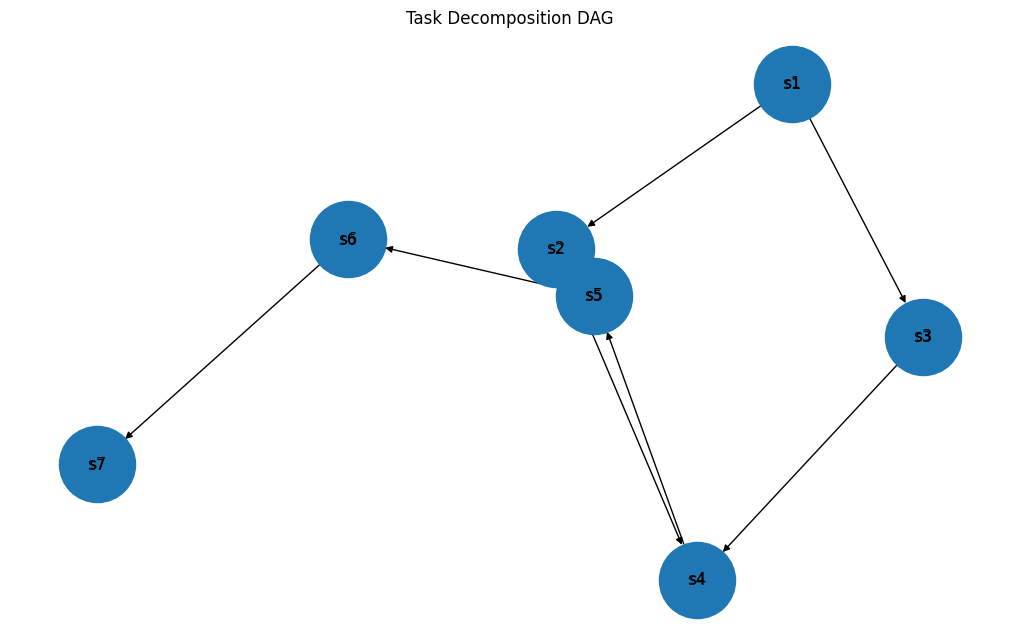

In [125]:
visualize_dag(result.subtasks)
